<a href="https://colab.research.google.com/github/JacekDrzycimski/6tunnel/blob/master/Bills_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Managing Bill Payments with Pandas
This notebook demonstrates how to load, filter, and aggregate your monthly bills using `pandas` to keep track of what you owe and when.

In [1]:
import pandas as pd
import datetime

# Let's create a sample dataset of bills
data = {
    'Bill ID': [101, 102, 103, 104, 105, 106],
    'Billed To': ['Electric Co.', 'Water Dept.', 'Internet Provider', 'Credit Card A', 'Streaming Service', 'Gas Utility'],
    'Category': ['Utilities', 'Utilities', 'Subscription', 'Finance', 'Subscription', 'Utilities'],
    'Amount': [120.50, 45.00, 79.99, 350.00, 15.99, 60.00],
    'Due Date': ['2023-11-05', '2023-11-10', '2023-11-12', '2023-11-15', '2023-11-18', '2023-11-20'],
    'Status': ['Paid', 'Pending', 'Pending', 'Pending', 'Paid', 'Pending']
}

# Convert to DataFrame
df = pd.DataFrame(data)

# Ensure Due Date is a datetime object
df['Due Date'] = pd.to_datetime(df['Due Date'])

display(df)

,Bill ID,Billed To,Category,Amount,Due Date,Status
0,101,Electric Co.,Utilities,120.50,2023-11-05,Paid
1,102,Water Dept.,Utilities,45.00,2023-11-10,Pending
2,103,Internet Provider,Subscription,79.99,2023-11-12,Pending
3,104,Credit Card A,Finance,350.00,2023-11-15,Pending
4,105,Streaming Service,Subscription,15.99,2023-11-18,Paid
5,106,Gas Utility,Utilities,60.00,2023-11-20,Pending


### 1. Find Pending Bills
Let's filter our dataframe to see which bills are still marked as `Pending` and calculate the total amount outstanding.

In [2]:
# Filter for Pending status
pending_bills = df[df['Status'] == 'Pending']
print("Pending Bills:")
display(pending_bills)

total_pending = pending_bills['Amount'].sum()
print(f"\nTotal Amount Due: ${total_pending:.2f}")

Pending Bills:


,Bill ID,Billed To,Category,Amount,Due Date,Status
1,102,Water Dept.,Utilities,45.00,2023-11-10,Pending
2,103,Internet Provider,Subscription,79.99,2023-11-12,Pending
3,104,Credit Card A,Finance,350.00,2023-11-15,Pending
5,106,Gas Utility,Utilities,60.00,2023-11-20,Pending



Total Amount Due: $534.99


In [3]:
# Calculate the total outstanding amount for the pending bills
total_outstanding = pending_bills['Amount'].sum()
print(f"Total outstanding amount for pending bills: ${total_outstanding:,.2f}")

Total outstanding amount for pending bills: $534.99


### 1.1. Visualizing Pending Bills
Let's plot a bar chart to compare the amounts of each pending bill.

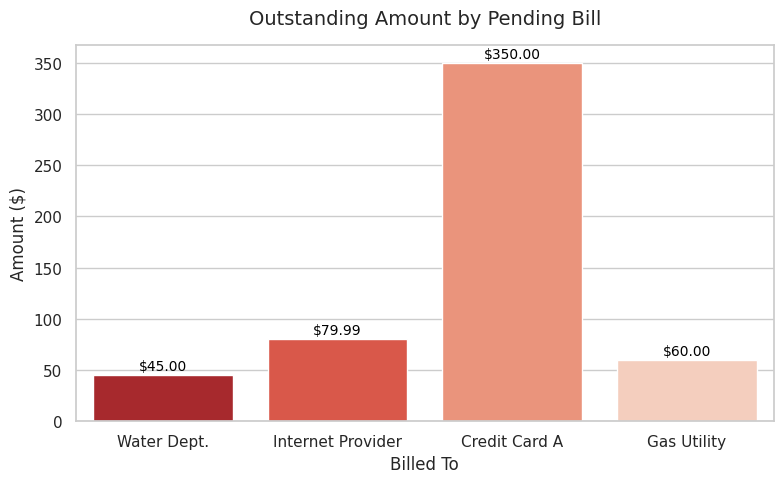

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 5))
sns.barplot(
    x='Billed To',
    y='Amount',
    data=pending_bills,
    palette='Reds_r',
    hue='Billed To',
    legend=False
)

# Add titles and labels
plt.title('Outstanding Amount by Pending Bill', fontsize=14, pad=15)
plt.xlabel('Billed To', fontsize=12)
plt.ylabel('Amount ($)', fontsize=12)

# Add values on top of the bars
for index, row in pending_bills.reset_index(drop=True).iterrows():
    plt.text(index, row['Amount'] + 5, f"${row['Amount']:.2f}", color='black', ha="center", fontsize=10)

plt.tight_layout()
plt.show()

### 2. Group Expenses by Category
Understanding where your money goes is crucial. Let's group all bills by category to see the total distribution.

In [5]:
category_summary = df.groupby('Category').agg(
    Total_Amount=('Amount', 'sum'),
    Count=('Bill ID', 'count')
).reset_index()

display(category_summary)

,Category,Total_Amount,Count
0,Finance,350.00,1
1,Subscription,95.98,2
2,Utilities,225.50,3


### 3. Visualizing Spending by Category
Let's create a bar chart to easily visualize our total expenses across the different categories.

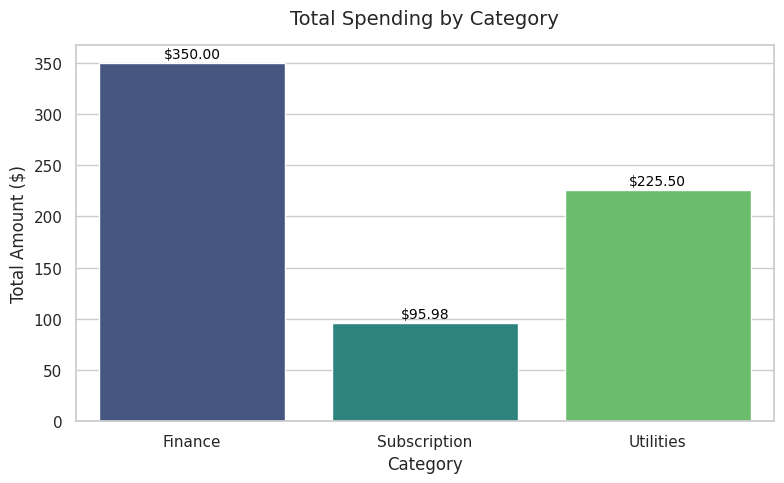

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style of the plots
sns.set_theme(style="whitegrid")

# Create a bar chart
plt.figure(figsize=(8, 5))
sns.barplot(
    x='Category',
    y='Total_Amount',
    data=category_summary,
    palette='viridis',
    hue='Category',
    legend=False
)

# Add titles and labels
plt.title('Total Spending by Category', fontsize=14, pad=15)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Total Amount ($)', fontsize=12)

# Display the values on top of the bars
for index, row in category_summary.iterrows():
    plt.text(index, row['Total_Amount'] + 5, f"${row['Total_Amount']:.2f}", color='black', ha="center", fontsize=10)

plt.tight_layout()

# Save the plot as a PNG file
plt.savefig('spending_by_category.png', dpi=300)

# Display the plot
plt.show()

### 4. Percentage Distribution of Spending
Let's visualize the relative contribution of each category to the total spending using a pie chart.

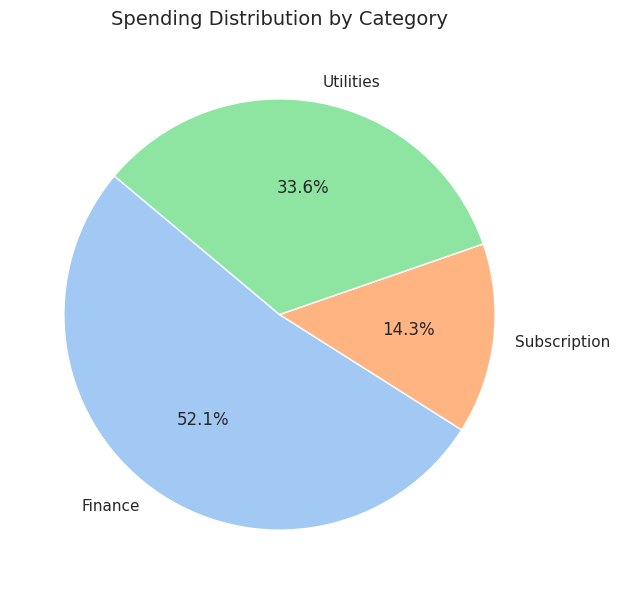

In [7]:
plt.figure(figsize=(7, 7))

# Create a pie chart
plt.pie(
    category_summary['Total_Amount'],
    labels=category_summary['Category'],
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette('pastel')[0:len(category_summary)]
)

# Add a title
plt.title('Spending Distribution by Category', fontsize=14, pad=15)

# Save the plot as a PNG file
plt.savefig('spending_distribution_pie.png', dpi=300)

# Display the plot
plt.show()

### 4.1. Individual Bill Amounts Comparison
Let's visualize the exact amount of each individual bill from our dataset using a bar chart.

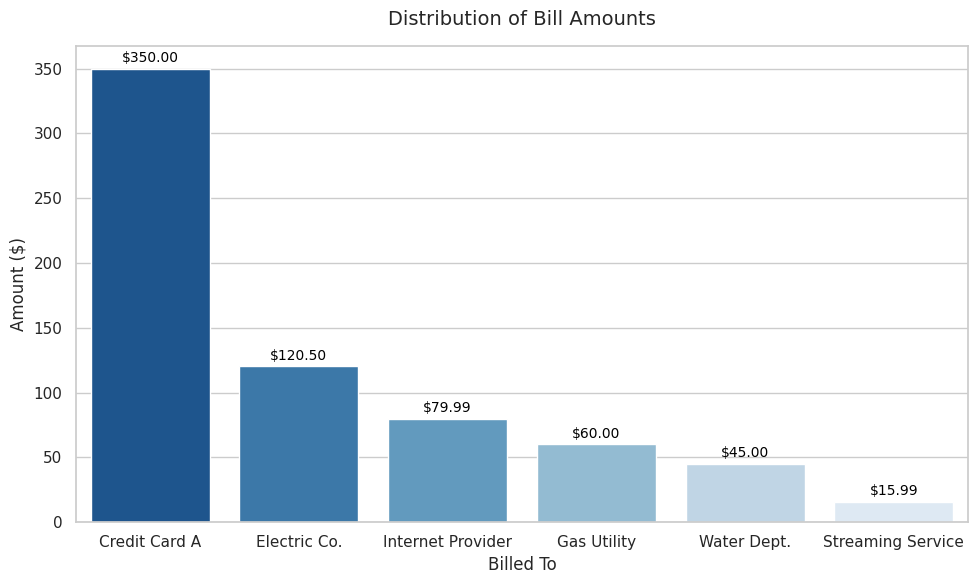

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort bills by amount for better visualization flow
df_sorted = df.sort_values(by='Amount', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    x='Billed To',
    y='Amount',
    data=df_sorted,
    palette='Blues_r',
    hue='Billed To',
    legend=False
)

# Add titles and labels
plt.title('Distribution of Bill Amounts', fontsize=14, pad=15)
plt.xlabel('Billed To', fontsize=12)
plt.ylabel('Amount ($)', fontsize=12)

# Display individual values on top of the bars
for index, row in df_sorted.reset_index(drop=True).iterrows():
    plt.text(index, row['Amount'] + 5, f"${row['Amount']:.2f}", color='black', ha="center", fontsize=10)

plt.tight_layout()
plt.show()

In [9]:
from google.colab import files

# Download the pie chart image file
files.download('spending_distribution_pie.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### 5. Average Bill Amount by Category
Let's calculate and display the average spending amount across each category.

In [10]:
# Group by Category and calculate the average bill amount
average_category_billing = df.groupby('Category')['Amount'].mean().reset_index(name='Average_Amount')

# Display the summary table
display(average_category_billing)

,Category,Average_Amount
0,Finance,350.000000
1,Subscription,47.990000
2,Utilities,75.166667


### 5.1. Category with the Highest Average Bill Amount
Let's determine which category has the highest average bill dynamically from our summary data.

In [11]:
# Find the category with the maximum average amount
highest_avg_row = average_category_billing.loc[average_category_billing['Average_Amount'].idxmax()]

category_name = highest_avg_row['Category']
average_val = highest_avg_row['Average_Amount']

print(f"The category with the highest average bill amount is '{category_name}' with an average of ${average_val:,.2f}.")

The category with the highest average bill amount is 'Finance' with an average of $350.00.


### 6. Upcoming Bills (Due in Next 7 Days)
Let's identify bills that are due within the next 7 days from today's date.

In [12]:
import pandas as pd
import datetime

# Get today's date
today = pd.to_datetime(datetime.date.today())

# Calculate the date 7 days from today
seven_days_from_now = today + pd.to_timedelta('7 days')

# Filter for pending bills that are due within the next 7 days
upcoming_bills = df[
    (df['Status'] == 'Pending') &
    (df['Due Date'] >= today) &
    (df['Due Date'] <= seven_days_from_now)
]

print("Upcoming Pending Bills (Due in next 7 days):")
display(upcoming_bills)

total_upcoming_due = upcoming_bills['Amount'].sum()
print(f"\nTotal Amount for Upcoming Pending Bills: ${total_upcoming_due:.2f}")

Upcoming Pending Bills (Due in next 7 days):


,Bill ID,Billed To,Category,Amount,Due Date,Status



Total Amount for Upcoming Pending Bills: $0.00


### 7. Pie Chart: Bill Counts by Category
Let's visualize the numerical distribution (number of bills) across different categories using a pie chart.

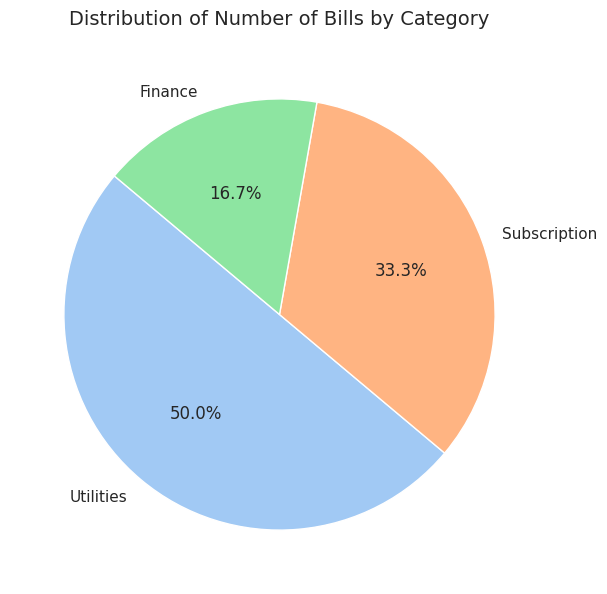

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for bill counts by category
category_counts = df['Category'].value_counts().reset_index()
category_counts.columns = ['Category', 'Count']

plt.figure(figsize=(7, 7))

# Create a pie chart representing the number of bills per category
plt.pie(
    category_counts['Count'],
    labels=category_counts['Category'],
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette('pastel')[0:len(category_counts)]
)

# Add a title
plt.title('Distribution of Number of Bills by Category', fontsize=14, pad=15)
plt.show()

### 8. Top 3 Largest Pending Bills
Let's filter for pending bills, sort them from highest to lowest amount, and display the top 3.

In [14]:
# Filter for pending bills and get the top 3 largest by Amount
top_3_pending = df[df['Status'] == 'Pending'].nlargest(3, 'Amount')

# Display the resulting subset
display(top_3_pending)

,Bill ID,Billed To,Category,Amount,Due Date,Status
3,104,Credit Card A,Finance,350.00,2023-11-15,Pending
2,103,Internet Provider,Subscription,79.99,2023-11-12,Pending
5,106,Gas Utility,Utilities,60.00,2023-11-20,Pending
